# Introduction #

In this exercise, I’ll be learning how to improve training outcomes by including an early stopping callback to prevent overfitting.

Let's run the next cell to set everything up!

In [1]:
# Setup plotting
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
# Set Matplotlib defaults
plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=18, titlepad=10)
plt.rc('animation', html='html5')

First we'll load the *Spotify* dataset. Our task will be to predict the popularity of a song based on various audio features, like `'tempo'`, `'danceability'`, and `'mode'`.

In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.model_selection import GroupShuffleSplit

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import callbacks

spotify = pd.read_csv('data/spotify.csv')

# This strips out any rows that have missing data (NaN values) so they don't crash the model later.
X = spotify.copy().dropna() 

# This separates the "target" (what you want to predict) from the "features" (what you use to make the prediction).
y = X.pop('track_popularity')

# It extracts a separate list of the artists for every song.
artists = X['track_artist'] 

# All 12 numerical features (like tempo and loudness) will go through StandardScaler to ensure their values are 
# scaled proportionately.
features_num = ['danceability', 'energy', 'key', 'loudness', 'mode',
                'speechiness', 'acousticness', 'instrumentalness',
                'liveness', 'valence', 'tempo', 'duration_ms']

# The single text/categorical feature (playlist_genre) will go through OneHotEncoder to be converted into columns 
# of 1s and 0s.
features_cat = ['playlist_genre']

preprocessor = make_column_transformer(
    (StandardScaler(), features_num),
    (OneHotEncoder(), features_cat),
)

# We'll do a "grouped" split to keep all of an artist's songs in one
# split or the other. This is to help prevent signal leakage.
def group_split(X, y, group, train_size=0.75):
    splitter = GroupShuffleSplit(train_size=train_size)
    train, test = next(splitter.split(X, y, groups=group))
    return (X.iloc[train], X.iloc[test], y.iloc[train], y.iloc[test])

X_train, X_valid, y_train, y_valid = group_split(X, y, artists)

X_train = preprocessor.fit_transform(X_train)
X_valid = preprocessor.transform(X_valid)
y_train = y_train / 100 # popularity is on a scale 0-100, so this rescales to 0-1.
y_valid = y_valid / 100

input_shape = [X_train.shape[1]]
print("Input shape: {}".format(input_shape))

Input shape: [18]


### Explanation of the code cell above

`splitter = GroupShuffleSplit(train_size=train_size)`. This is the most advanced and important part of this script! Normally, you just shuffle rows randomly to split your training and validation data. But imagine an artist like Taylor Swift has 10 songs in this dataset. If you shuffle randomly, 7 of her songs might end up in the training data, and 3 might end up in the validation data.

The neural network might just memorize that "Taylor Swift = High Popularity" instead of actually learning which audio features (like danceability or tempo) make a song popular. When it sees the 3 Taylor Swift songs in the validation set, it will cheat and guess correctly based on the artist, not the features. This is called Data Leakage.

`GroupShuffleSplit` fixes this by looking at the artists list we made in Step 1. It ensures that all of an artist's songs go into the training set, OR all of their songs go into the validation set. They are never split across both.

Notice a tiny but crucial detail here:

- X_train uses .fit_transform(): This tells the scalers to calculate the averages/ranges of the training data AND apply the scaling.

- X_valid uses .transform(): This tells the scalers to apply the scaling using the math it already learned from the training data. It does not look at the validation data to calculate averages. This ensures the validation data remains a complete surprise to the model!

- **Scaling y**: The original track_popularity scores are from 0 to 100. Neural networks work best with small numbers, so dividing by 100 shrinks all the targets down to a scale of 0.0 to 1.0.

- **Input Shape**: Because OneHotEncoder creates brand new columns for every unique playlist genre, you can no longer just count the original columns to know how many inputs your model needs. X_train.shape[1] dynamically checks exactly how many columns exist after the preprocessing is finished, so you can pass that number directly into your first Keras Dense layer.

Let's continue our solution by starting with the simplest network, a linear model. This model has low capacity.

Run this next cell without any changes to train a linear model on the Spotify dataset.

Minimum Validation Loss: 0.1938


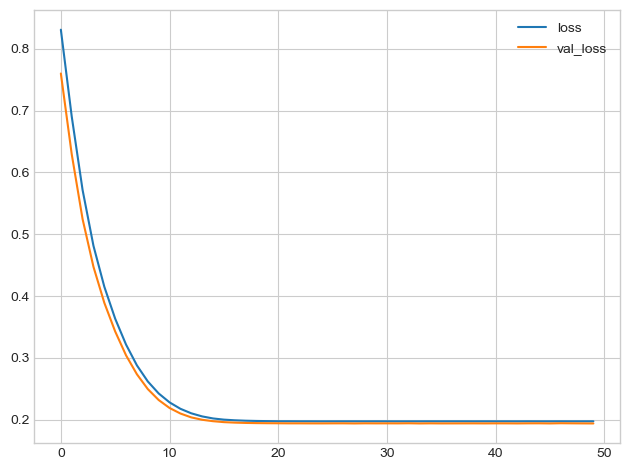

In [4]:
model = keras.Sequential([
    keras.Input(shape=input_shape),
    layers.Dense(1),
])
model.compile(
    optimizer='adam',
    loss='mae',
)
history = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    batch_size=512,
    epochs=50,
    verbose=0, # suppress output since we'll plot the curves
)
history_df = pd.DataFrame(history.history)
history_df.loc[0:, ['loss', 'val_loss']].plot()
print("Minimum Validation Loss: {:0.4f}".format(history_df['val_loss'].min()));

It's not uncommon for the curves to follow a "hockey stick" pattern like you see here. This makes the final part of training hard to see, so let's start at epoch 10 instead:

Minimum Validation Loss: 0.1938


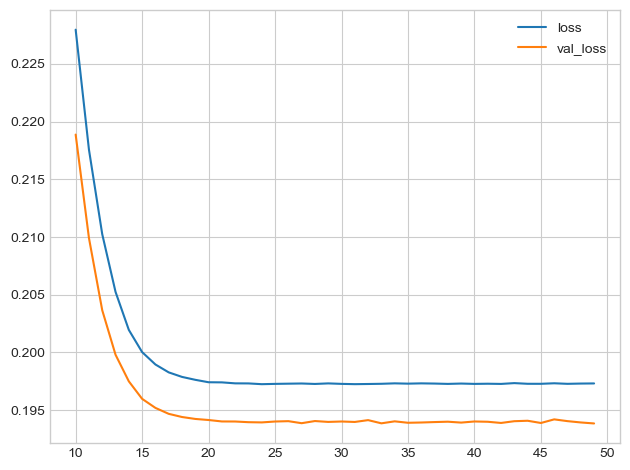

In [5]:
# Start the plot at epoch 10
history_df.loc[10:, ['loss', 'val_loss']].plot()
print("Minimum Validation Loss: {:0.4f}".format(history_df['val_loss'].min()));

# 1) Evaluate Baseline

What do you think? Would you say this model is underfitting, overfitting, just right?

The gap between these curves is quite small and the validation loss never increases, so it's more likely that the network is underfitting than overfitting. It would be worth experimenting with more capacity to see if that's the case.

Now let's add some capacity to our network. We'll add three hidden layers with 128 units each. Run the next cell to train the network and see the learning curves.

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2562 - val_loss: 0.2081
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2038 - val_loss: 0.2017
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1980 - val_loss: 0.1985
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1948 - val_loss: 0.1997
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1927 - val_loss: 0.1985
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1919 - val_loss: 0.1975
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1896 - val_loss: 0.1970
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1883 - val_loss: 0.1962
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1867 - val_loss: 0.1958
Epoch 10/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1861 - val_loss: 0.1950
Epoch 11/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1853 - val_loss: 0.1959
Epoch 12/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1839 - val_lo

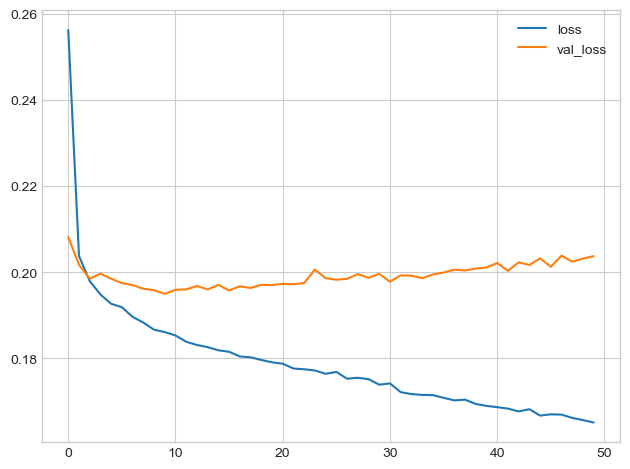

In [6]:
model = keras.Sequential([
    keras.Input(shape=input_shape),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)
])
model.compile(
    optimizer='adam',
    loss='mae',
)
history = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    batch_size=512,
    epochs=50,
)
history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot()
print("Minimum Validation Loss: {:0.4f}".format(history_df['val_loss'].min()));

# 2) Add Capacity

What is your evaluation of these curves? Underfitting, overfitting, just right?

Now the validation loss begins to rise very early, while the training loss continues to decrease. This indicates that the network has begun to overfit. At this point, we would need to try something to prevent it, either by reducing the number of units or through a method like early stopping. (We'll see another in the next lesson!)

# 3) Define Early Stopping Callback

Now define an early stopping callback that waits 5 epochs (`patience'`) for a change in validation loss of at least `0.001` (`min_delta`) and keeps the weights with the best loss (`restore_best_weights`).

In [7]:
from tensorflow.keras import callbacks

early_stopping = callbacks.EarlyStopping(
    min_delta=0.001,
    patience=5,
    restore_best_weights=True
)

Now let's run this cell to train the model and get the learning curves. Notice the `callbacks` argument in `model.fit`.

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2817 - val_loss: 0.2102
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2035 - val_loss: 0.2027
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1985 - val_loss: 0.1994
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1953 - val_loss: 0.1991
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1935 - val_loss: 0.1985
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1913 - val_loss: 0.1973
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1898 - val_loss: 0.1964
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1887 - val_loss: 0.1957
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1881 - val_loss: 0.1961
Epoch 10/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1869 - val_loss: 0.1956
Epoch 11/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1868 - val_loss: 0.1945
Epoch 12/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1853 - val_lo

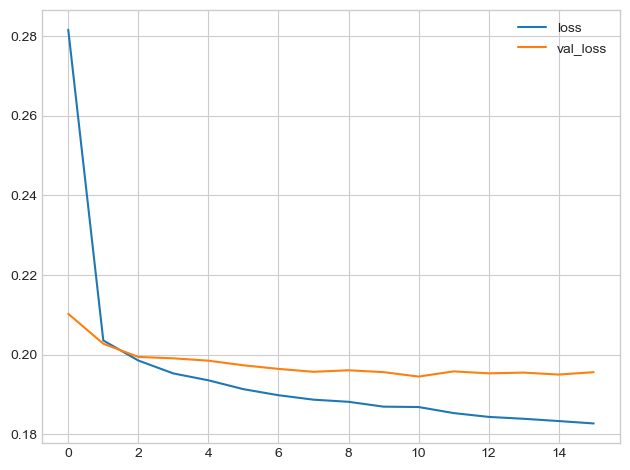

In [8]:
model = keras.Sequential([
    keras.Input(shape=input_shape),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),    
    layers.Dense(1)
])
model.compile(
    optimizer='adam',
    loss='mae',
)
history = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    batch_size=512,
    epochs=50,
    callbacks=[early_stopping]
)
history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot()
print("Minimum Validation Loss: {:0.4f}".format(history_df['val_loss'].min()));

# 4) Train and Interpret

Was this an improvement compared to training without early stopping?

The early stopping callback did stop the training once the network began overfitting. Moreover, by including restore_best_weights we still get to keep the model where validation loss was lowest.